# MLP v5 — Red neuronal sklearn sobre `ACCEL_RMS` (Fase 9, experimental)

**Objetivo.** Entrenar y evaluar un perceptrón multicapa (sklearn `MLPRegressor`, CPU) sobre el target
`ACCEL_RMS` en condición `all` con la **misma partición temporal por días** y el **mismo preprocesamiento
fit-on-train** del registro principal, y compararlo honestamente contra el baseline documentado
**LightGBM R² = 0.8547**.

**Contexto.** Evidencia previa de la Fase 9: MLP v1 (1 modelo, R² 0.7721), v2 big (7 modelos, 0.7883),
v4 long (74 modelos, mejor 0.8002). Este notebook v5 reproduce de forma autocontenida y ejecutada la
configuración ganadora de v4 más una referencia pequeña de control.

**Reglas de salida:** no se muestran filas crudas del dataset; solo shapes, columnas, hiperparámetros,
métricas y gráficas agregadas.

*Documento experimental de la rama `phase-9-neural-network`. No forma parte del entregable de la memoria.*

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("sklearn:", sklearn.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

sklearn: 1.8.0 | pandas: 3.0.3 | numpy: 2.4.3


## 1. Carga de artefactos preprocesados

Se cargan `df_train.csv` y `df_test.csv`, productos del pipeline reproducible (partición temporal por
días: 16 de entrenamiento + 4 de prueba, sin barajado). No se recalcula ningún filtrado: la partición
y el preprocesamiento son exactamente los del registro principal.

In [2]:
REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

train = pd.read_csv(REPO / "df_train.csv")
test = pd.read_csv(REPO / "df_test.csv")

ALL_TARGETS = ["ACCEL_PEAK", "ACCEL_RMS", "ACCEL_RMS_FREQ"]
TARGET = "ACCEL_RMS"
BASELINE_LIGHTGBM_R2 = 0.8547

drop_cols = [c for c in ALL_TARGETS + ["DATE"] if c in train.columns]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

print("df_train:", train.shape, "| df_test:", test.shape)
print("N features:", len(feature_cols))
print("Features:", feature_cols)
print("Target:", TARGET, "| condicion: all | baseline LightGBM R2 =", BASELINE_LIGHTGBM_R2)

df_train: (172132, 32) | df_test: (35832, 32)
N features: 28
Features: ['B', 'CURR_B', 'CURR_X', 'CURR_Y', 'CURR_Z', 'FEED_HOLD', 'LAST_M_CODE', 'PROG_BLOCK_NUM', 'PROG_NAME_ACTIVE', 'PROG_STATUS', 'RAPID_OVERRIDE', 'RAPID_TRAVERSING', 'SPEED_RMS', 'SPINDLE_ACTUAL_FEED', 'SPINDLE_ACTUAL_SPEED', 'SPINDLE_LOAD', 'TEMPERATURE', 'X', 'Y', 'Z', 'JOG_OVERRIDE_47.0', 'SPINDLE_OVERRIDE_X105_60.0', 'SPINDLE_OVERRIDE_X105_70.0', 'SPINDLE_OVERRIDE_X105_80.0', 'SPINDLE_OVERRIDE_X105_90.0', 'SPINDLE_OVERRIDE_X105_100.0', 'SPINDLE_OVERRIDE_X105_120.0', 'SPINDLE_OVERRIDE_X105_420.0']
Target: ACCEL_RMS | condicion: all | baseline LightGBM R2 = 0.8547


## 2. Modelo y escalado fit-on-train

Mismo pipeline que las iteraciones v2/v4: imputación por mediana + `StandardScaler` sobre las entradas,
y `TransformedTargetRegressor` con `StandardScaler` sobre el target. Al ir dentro de un `Pipeline`,
**todos los escaladores se ajustan exclusivamente sobre el conjunto de entrenamiento**.

Configuraciones:
1. **v5_ref** — control pequeño (256, 128).
2. **v5_best_v4** — la configuración ganadora de la búsqueda v4: (2048, 1024, 512), relu,
   α=1e-5, lr=3e-4, batch 2048, seed 123 (R² 0.8002 en v4).

In [3]:
MAX_ITER = 1200
EARLY_STOPPING = True
VALIDATION_FRACTION = 0.15
N_ITER_NO_CHANGE = 40
TOL = 1e-4


def build_model(cfg):
    regressor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=cfg["hidden_layer_sizes"],
            activation=cfg["activation"],
            solver="adam",
            alpha=cfg["alpha"],
            batch_size=cfg["batch_size"],
            learning_rate_init=cfg["learning_rate_init"],
            max_iter=MAX_ITER,
            early_stopping=EARLY_STOPPING,
            validation_fraction=VALIDATION_FRACTION,
            n_iter_no_change=N_ITER_NO_CHANGE,
            tol=TOL,
            random_state=cfg["random_state"],
            verbose=False,
        )),
    ])
    return TransformedTargetRegressor(regressor=regressor, transformer=StandardScaler())


CONFIGS = [
    {"experiment": "v5_ref_256_128", "hidden_layer_sizes": (256, 128), "activation": "relu",
     "alpha": 1e-4, "learning_rate_init": 1e-3, "batch_size": 2048, "random_state": 42},
    {"experiment": "v5_best_v4_2048_1024_512", "hidden_layer_sizes": (2048, 1024, 512),
     "activation": "relu", "alpha": 1e-5, "learning_rate_init": 3e-4, "batch_size": 2048,
     "random_state": 123},
]

for c in CONFIGS:
    print(c)

{'experiment': 'v5_ref_256_128', 'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 2048, 'random_state': 42}
{'experiment': 'v5_best_v4_2048_1024_512', 'hidden_layer_sizes': (2048, 1024, 512), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.0003, 'batch_size': 2048, 'random_state': 123}


## 3. Entrenamiento y métricas (test temporal)

In [4]:
rows = []
for cfg in CONFIGS:
    print("=" * 70)
    print("Entrenando:", cfg["experiment"], "| arquitectura:", cfg["hidden_layer_sizes"])
    model = build_model(cfg)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    pred = model.predict(X_test)
    mlp = model.regressor_.named_steps["mlp"]

    mse = float(mean_squared_error(y_test, pred))
    row = {
        "experiment": cfg["experiment"],
        "model": "MLPRegressor",
        "target": TARGET,
        "load_condition": "all",
        "output_mode": "single",
        "hidden_layer_sizes": str(cfg["hidden_layer_sizes"]),
        "activation": cfg["activation"],
        "alpha": cfg["alpha"],
        "learning_rate_init": cfg["learning_rate_init"],
        "batch_size": cfg["batch_size"],
        "max_iter": MAX_ITER,
        "early_stopping": EARLY_STOPPING,
        "validation_fraction": VALIDATION_FRACTION,
        "n_iter_no_change": N_ITER_NO_CHANGE,
        "tol": TOL,
        "random_state": cfg["random_state"],
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "n_features": int(len(feature_cols)),
        "mae": float(mean_absolute_error(y_test, pred)),
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "r2": float(r2_score(y_test, pred)),
        "baseline_lightgbm_r2": BASELINE_LIGHTGBM_R2,
        "n_iter": int(mlp.n_iter_),
        "best_validation_score": float(getattr(mlp, "best_validation_score_", float("nan"))),
        "fit_s": float(fit_s),
        "notes": "Notebook MLP v5; experimental Fase 9; sklearn CPU.",
    }
    row["delta_r2_vs_lightgbm"] = row["r2"] - BASELINE_LIGHTGBM_R2
    rows.append(row)
    print(f"fit_s={fit_s:.1f}s | n_iter={row['n_iter']} | MAE={row['mae']:.3f} "
          f"| RMSE={row['rmse']:.3f} | R2={row['r2']:.4f} "
          f"| delta vs LightGBM={row['delta_r2_vs_lightgbm']:+.4f}")

Entrenando: v5_ref_256_128 | arquitectura: (256, 128)


fit_s=86.2s | n_iter=136 | MAE=38.137 | RMSE=64.688 | R2=0.7987 | delta vs LightGBM=-0.0560
Entrenando: v5_best_v4_2048_1024_512 | arquitectura: (2048, 1024, 512)


fit_s=985.4s | n_iter=85 | MAE=32.582 | RMSE=64.437 | R2=0.8002 | delta vs LightGBM=-0.0545


## 4. Resultados y persistencia

In [5]:
results = pd.DataFrame(rows)
metric_cols = ["experiment", "hidden_layer_sizes", "n_iter", "fit_s", "mae", "mse",
               "rmse", "r2", "best_validation_score", "delta_r2_vs_lightgbm"]
display(results[metric_cols].round(4))

OUT = REPO / "reports" / "results" / "neural_mlp_v5_results.csv"
results.to_csv(OUT, index=False)
print("Guardado:", OUT, "|", results.shape)

,experiment,hidden_layer_sizes,n_iter,fit_s,mae,mse,rmse,r2,best_validation_score,delta_r2_vs_lightgbm
0,v5_ref_256_128,"(256, 128)",136,86.1742,38.1373,4184.5246,64.6879,0.7987,0.8555,-0.0560
1,v5_best_v4_2048_1024_512,"(2048, 1024, 512)",85,985.3929,32.5815,4152.1592,64.4372,0.8002,0.8515,-0.0545


Guardado: reports/results/neural_mlp_v5_results.csv | (2, 29)


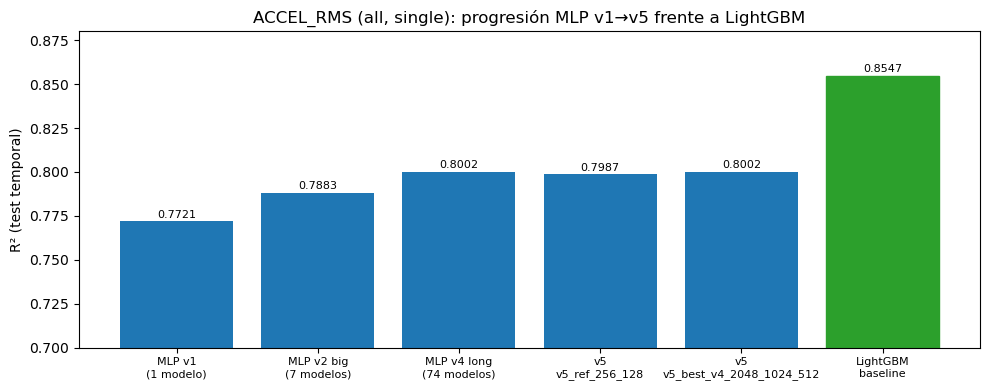

In [6]:
hist = {"MLP v1\n(1 modelo)": 0.7721, "MLP v2 big\n(7 modelos)": 0.7883,
        "MLP v4 long\n(74 modelos)": 0.8002}
names = list(hist.keys()) + [f"v5\n{e}" for e in results["experiment"]] + ["LightGBM\nbaseline"]
vals = list(hist.values()) + results["r2"].tolist() + [BASELINE_LIGHTGBM_R2]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(vals)), vals, color="tab:blue")
bars[-1].set_color("tab:green")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(names, fontsize=8)
ax.set_ylim(0.70, 0.88)
ax.set_ylabel("R² (test temporal)")
ax.set_title("ACCEL_RMS (all, single): progresión MLP v1→v5 frente a LightGBM")
for i, v in enumerate(vals):
    ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Veredicto frente al baseline

In [7]:
best = results.loc[results["r2"].idxmax()]
print("Mejor MLP v5:", best["experiment"])
print(f"R2 v5 = {best['r2']:.4f} | baseline LightGBM = {BASELINE_LIGHTGBM_R2}")
if best["r2"] > BASELINE_LIGHTGBM_R2:
    print("VEREDICTO: el MLP v5 SUPERA al baseline LightGBM en este test temporal.")
else:
    print(f"VEREDICTO: el MLP v5 NO supera al baseline LightGBM "
          f"(deficit = {BASELINE_LIGHTGBM_R2 - best['r2']:.4f} puntos de R2).")
    print("Se mantiene la conclusion del registro principal: el boosting de arboles "
          "sigue siendo superior para este problema tabular industrial.")

Mejor MLP v5: v5_best_v4_2048_1024_512
R2 v5 = 0.8002 | baseline LightGBM = 0.8547
VEREDICTO: el MLP v5 NO supera al baseline LightGBM (deficit = 0.0545 puntos de R2).
Se mantiene la conclusion del registro principal: el boosting de arboles sigue siendo superior para este problema tabular industrial.


## 6. Conclusión

El veredicto impreso en la celda anterior se calcula directamente de las métricas de esta ejecución,
sin cifras manuales. La evidencia acumulada de la Fase 9 (v1: 1 modelo; v2: 7; v4: 74; v5: este
notebook autocontenido) es consistente: los MLP densos sobre estas variables tabulares se estabilizan
en torno a R² ≈ 0.78–0.80 sobre `ACCEL_RMS`, por debajo del baseline LightGBM (0.8547). El gap entre
la validación interna (fracción aleatoria del periodo de entrenamiento) y el test temporal refleja
además la deriva temporal del proceso, que penaliza más a la red que al boosting.

**Este resultado no altera la memoria entregable:** confirma su conclusión y queda como evidencia
experimental de la rama `phase-9-neural-network`.